# Tirando sinais digitais - $x[n]$ ... pra fora do computador - $x(t)$!

Neste Notebook iremos trabalhar em como:
1. Criar um sinal `osc`, com frequência e duração controladas.
2. Sintetizar um sinal ***periódico e aleatório***, com frequência e duração controladas.
3. Plotar sinais em amostras, $x[n]$, tempo, $x(t)$, e frequência, $\mathcal{X}(\omega)$.

Murilo Uchôa 202504021

Mateus Nery  202504020

In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
import sys, os

In [21]:
try:
    from google.colab import drive

    drive.mount('/content/drive')
    sys.path.append('/content/drive/MyDrive/PDSI/')

except:
    sys.path.append(os.path.abspath('../..'))

In [22]:
from lib.myAudioProcessingLib import *
from lib.mySignalProcessingLib import *
from lib.myPlotLib import *

Complete a função `create_sine_signal`, que permite criar um **sinal oscilatório** (*le03, p. 24*):

$$
\Large
x[n] = \, \sin(\omega_{0} \, n + \theta), \quad \omega_{0} = \frac{2 \pi f}{f_{s}}
$$

controlado pela sua:

- ***frequência*** $(f)$ [Hz] (*le04, p. 11*):

$$
\Large
f = \, \frac{1}{M \, T_{s}} = \frac{f_{s}}{M}
$$

- e ***duração*** $(d)$ [s] :

$$
\Large
d = N \, T_{s}
$$

In [23]:
def create_sine_signal(f=440.0, dur=1.0, fs=48e3):
    '''
    f  : Signal frequency (Hz)
    dur: Duration (s)
    fs : Sampling frequency
    '''

    N = int(dur * fs)
    n = np.arange(N)
    x = np.sin(2 * np.pi * f * n / fs)

    return x, fs

teste sua função, para um sinal de 220 Hz e 1.5 segundos de duração:

In [65]:
f   = 220.0
dur = 1.5

x1, fs1 = create_sine_signal(f, dur)

In [64]:
play(x1, fs1)

Qual é a ***frequencia audível*** do sinal?

In [ ]:
# 220 Hz, a mesma que passamos para a funcao

Qual é o período $(P_{1})$, tamanho $(N_{1})$, e frequência de amostragem $(f_{s_{1}})$ do sinal?

In [27]:
P1 = fs1 / f
N1 = len(x1)

print(P1, N1, fs1)

218.1818181818182 72000 48000.0


Se mudar a frequencia de amostragem, o que acontece?

In [ ]:
# A nota continua a mesma (f em Hz nao muda), mas o periodo em
# amostras P = fs/f muda, e o sinal passa a ter mais (ou menos) amostras

Agora vamos recriar a mesma função a partir da nossa conhecida primitiva `osc`:

In [29]:
fs2  = 44.1e3

P2 = fs2 / f
N2 = int(dur * fs2)

x2, n2 = SIGNALgenerate(N=N2, signal='osc', period=P2)

In [30]:
play(x2, fs2)

Compare o período $(P_{2})$, tamanho $(N_{2})$, e frequência de amostragem $(f_{s_{2}})$ deste novo sinal com o anterior:

In [31]:
print(P2, N2, fs2)

print(P1, N1, fs1)

200.45454545454547 66150 44100.0
218.1818181818182 72000 48000.0


In [ ]:
# P e N mudam (fs diferente), mas a frequencia audivel e a mesma,
# porque f = fs/P se mantem em 220 Hz nos dois casos

Para verificar o resultado, plote os dois sinais resultantes no "***domínio do tempo***", ou seja, mostrando o **eixo horizontal** em unidade de **segundos**:

$$
\Large
t = n \, T_{s}
$$

***Dica:*** Use `SIGNALplot` para plotar o sinal. \
Se precisar, faça um recorte para melhorar a visualização dos sinais.

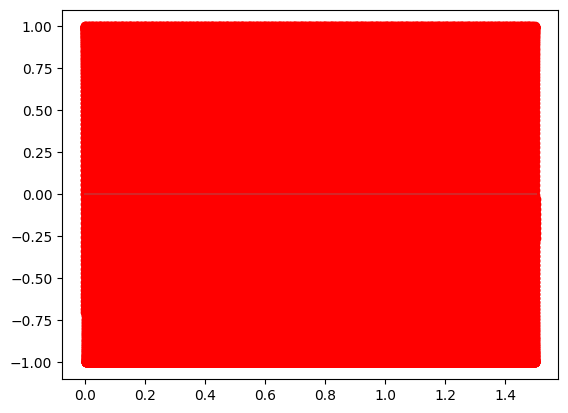

In [33]:
'''
Vetor de tempo
'''
n1 = np.arange(N1)
t1 = n1 / fs1

'''
Plot
'''
SIGNALplot(x1, t1)

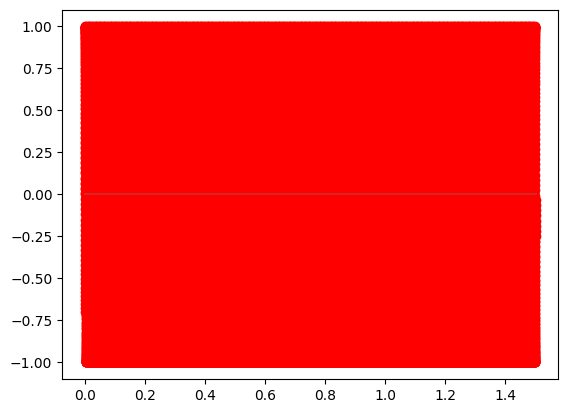

In [34]:
'''
Vetor de tempo
'''
t2 = n2 / fs2

'''
Plot
'''
SIGNALplot(x2, t2)

<img src="./figures/sine_01.png" alt="" width="600"/>

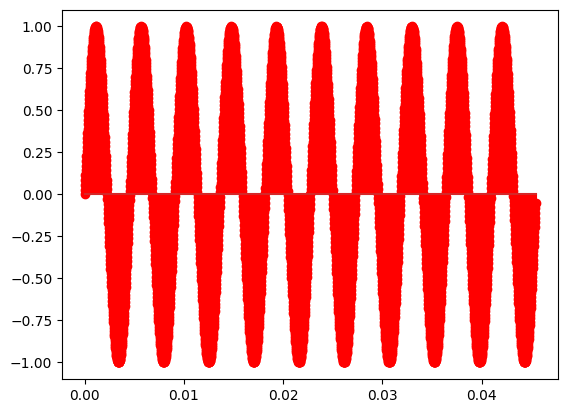

In [35]:
'''
Recorte
'''
r = int(10 * P1)

'''
Plot
'''
SIGNALplot(x1[:r], t1[:r])

<img src="./figures/sine_02.png" alt="" width="600"/>

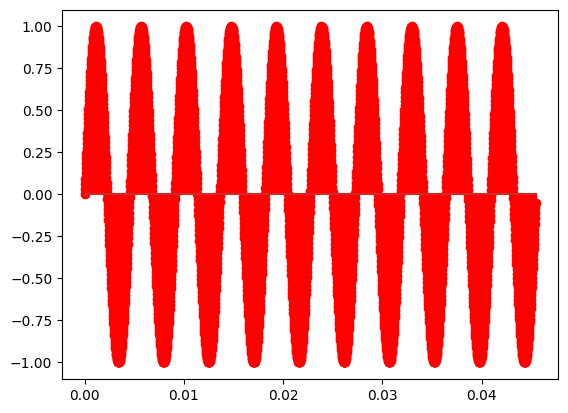

In [36]:
'''
Recorte
'''
r = int(10 * P2)

'''
Plot
'''
SIGNALplot(x2[:r], t2[:r])

Faça um novo recorte para plotar ***apenas*** 2.5 períodos de cada sinal.

***Dica:*** Verifique o resultado mostrando o **eixo horizontal** no "***domínio das amostras***".

<img src="./figures/sine_03.png" alt="" width="600"/>

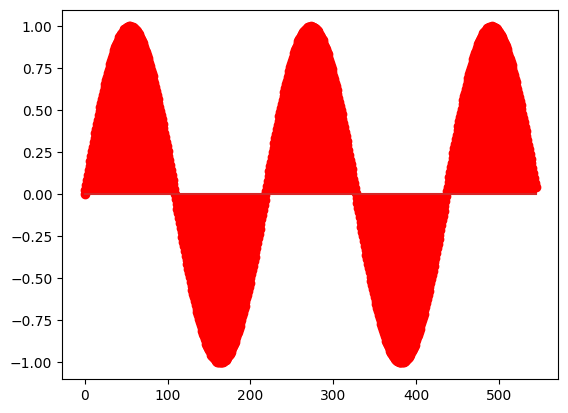

In [37]:
'''
Recorte
'''
r = int(2.5 * P1)

SIGNALplot(x1[:r], n1[:r])

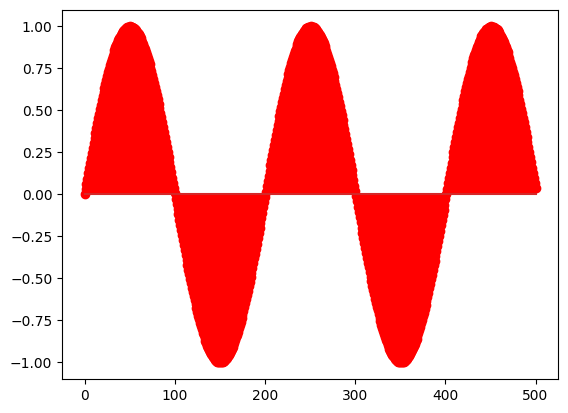

In [38]:
'''
Recorte
'''
r = int(2.5 * P2)

SIGNALplot(x2[:r], n2[:r])

## Desafio

A partir da primitiva `SIGNALgenerate`, aumente a sua **biblioteca de processamento sinais** com a função `SIGNALtone`, que permita criar um ***tom*** controlado por ***frequencia*** e ***duração***.

In [39]:
def SIGNALtone(f=440.0, dur=1.0):
    '''
    Tone with predefined frequency and duration

    f  : Signal frequency (Hz)
    dur: Duration (s)

    x  : Output signal
    fs : Sampling freq. (CD standard by def.)
    '''

    fs = 44.1e3 # Sampling freq. (CD standard)

    x, _ = SIGNALgenerate(N=int(dur * fs), signal='osc', period=fs / f)

    return x, fs

Teste a função para um sinal de 330 Hz com 3 segundos de duração.

In [40]:
f = 330.0 # signal freq (Hz)
dur = 3.0 # duration (s)

In [41]:
x, fs = SIGNALtone(f, dur)

In [42]:
play(x, fs)

## Revelando a "*velocidade*" dos sinais

Como comprovar que estamos gerando as frequências corretas?

***Dica:*** Estude a função `np.fft.fft` que permite evidenciar as "*velocidades*" de sinais. \
Use `SIGNALplot` para plotar a **magnitude** da FFT no domínio das amostras.

<img src="./figures/spec_01.png" alt="" width="600"/>

In [43]:
# help(np.fft.fft)

In [ ]:
# A FFT mostra a magnitude de cada frequencia presente no sinal,
# entao o pico revela a frequencia gerada

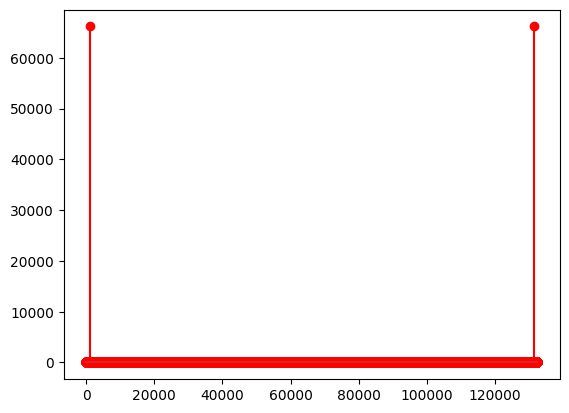

In [45]:
Xmag = np.abs(np.fft.fft(x))
n = np.arange(len(Xmag))

SIGNALplot(Xmag, n)

Aproveitando a ***simetria***, faça um recorte, apropriado, de apenas a metade das amostras.

<img src="./figures/spec_02.png" alt="" width="600"/>

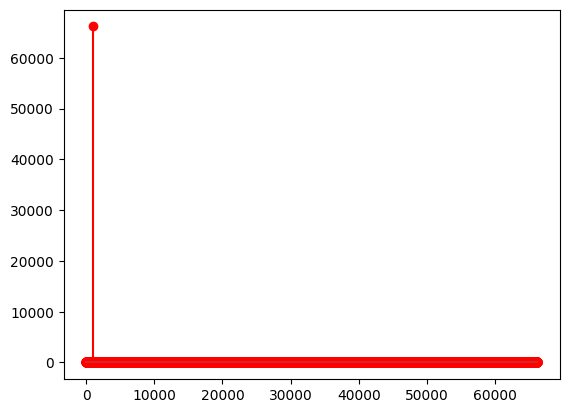

In [46]:
'''
Recorte no dominio das amostras
'''
r = len(Xmag) // 2

SIGNALplot(Xmag[:r], n[:r])

## Plotando as frequências

Agora vamos renomear o eixo horizontal para apresentar o sinal no "***domínio da frequência***":

$$
\Large
f = \frac{n}{N} f_{s}
$$

<img src="./figures/spec_03.png" alt="" width="600"/>

In [47]:
fHz = n / len(Xmag) * fs

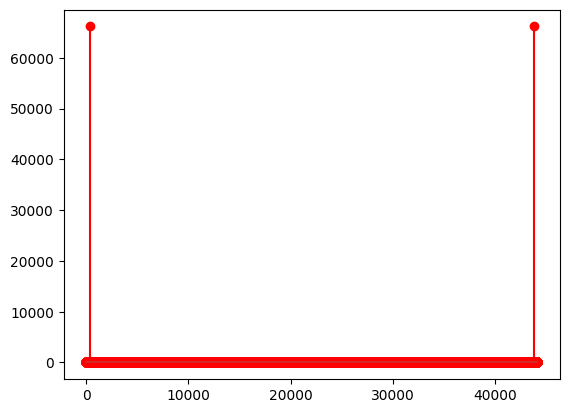

In [48]:
SIGNALplot(Xmag, fHz)

Aproveite o recorte anterior **no domínio das amostras** e aplique-o no sinal.

<img src="./figures/spec_04.png" alt="" width="600"/>

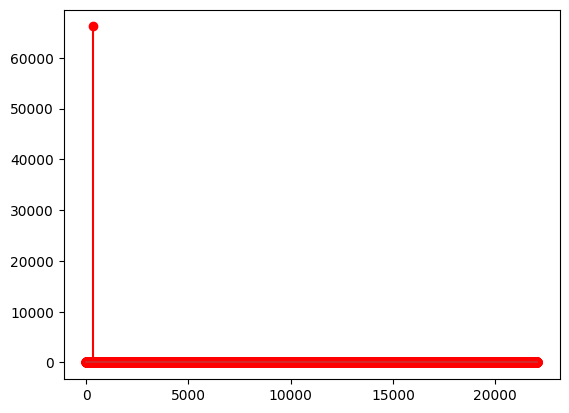

In [49]:
'''
Recorte no dominio das amostras
'''
r = len(Xmag) // 2

SIGNALplot(Xmag[:r], fHz[:r])

Agora, aplique um recorte similar **no domínio das frequências**.

<img src="./figures/spec_05.png" alt="" width="600"/>

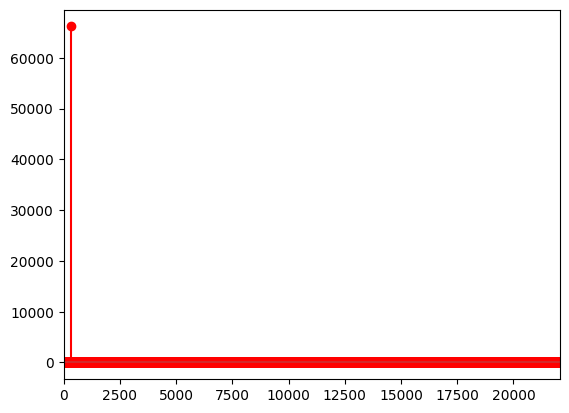

In [50]:
'''
Recorte no dominio das frequencias
'''
SIGNALplot(Xmag, fHz, \
           xlim=[ 0, fs/2 ])

Plote a ***forma de onda*** e o ***espectro*** para um único sinal com frequencias de 200, 400, 600 e 800 Hz e 1 segundo de duração.

<img src="./figures/sine_04.png" alt="" width="600"/>

<img src="./figures/spec_06.png" alt="" width="600"/>

In [51]:
fs_x = 44.1e3
dur  = 1.0

x = np.zeros(int(dur * fs_x))
for f0 in [200.0, 400.0, 600.0, 800.0]:
    xi, _ = create_sine_signal(f0, dur, fs_x)
    x = x + xi

nx = np.arange(len(x))
tx = nx / fs_x

Xmag  = np.abs(np.fft.fft(x))
fHz_x = nx / len(x) * fs_x

In [52]:
play(x, fs_x)

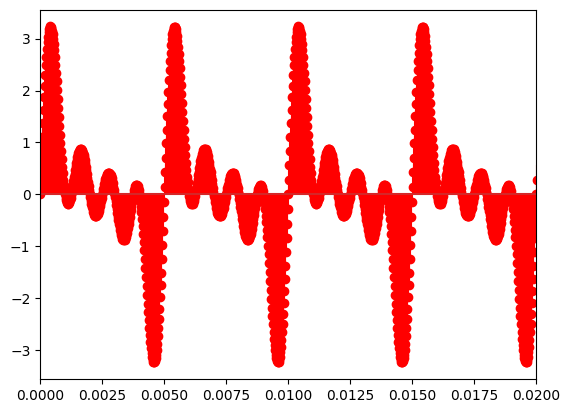

In [53]:
SIGNALplot(x, tx, \
          xlim=[ 0, 0.02 ])

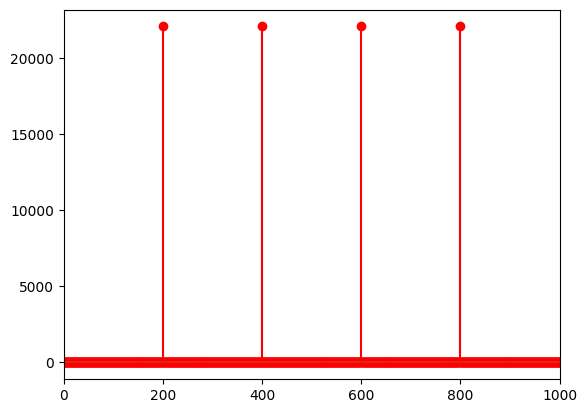

In [54]:
SIGNALplot(Xmag, fHz_x, \
           xlim=[ 0, 1000 ])

Oba! Agora sim conseguimos gerar e comprovar as frequencias, ou "*velocidades*", presentes nos sinais!

## Bonus track

A partir da primitiva `SIGNALgenerate`, aumente a sua **biblioteca de processamento sinais** com a função `SIGNALwaveform`, que admita ***tons*** com [***formas de onda*** (*waveforms*)](https://en.wikipedia.org/wiki/Waveform) aleatórias.

***Dica:*** Comece criando um sinal aleatório de tamanho igual a um período. Depois é apenas replicar o sinal até o tamanho final usando `np.concatenate`.

In [55]:
def SIGNALwaveform(f=440.0, dur=1.0):
    '''
    Tone with a random waveform as input

    f  : Signal frequency
    dur: Duration (seconds)

    x  : Output signal
    fs : Sampling freq. (CD standard by def.)
    '''

    fs = 44.1e3 # Sampling freq. (CD standard)

    P = int(fs / f)
    N = int(dur * fs)

    waveform, _ = SIGNALgenerate(N=P, signal='random')
    x = np.concatenate([waveform] * int(np.ceil(N / P)))[:N]

    return x, fs

Teste a função para um sinal de 110 Hz e 1 segundo de duração.

In [56]:
f = 110.0
dur = 1.0

y, fs = SIGNALwaveform(f, dur)

In [57]:
play(y, fs)

Verifique a frequencia do sinal gerado. \
O que achou de diferente nele?

<img src="./figures/spec_07.png" alt="" width="600"/>

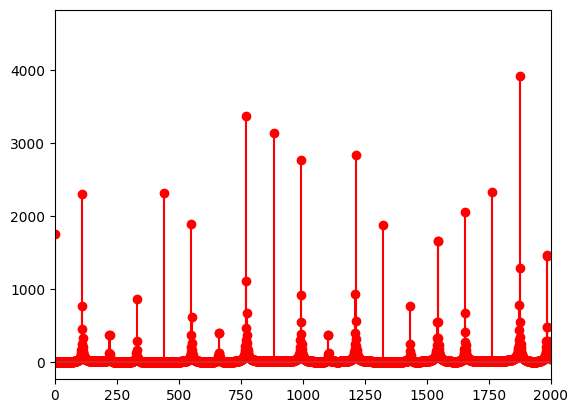

In [ ]:
ny    = np.arange(len(y))
Ymag  = np.abs(np.fft.fft(y))
fHz_y = ny / len(y) * fs

SIGNALplot(Ymag, fHz_y, \
           xlim=[ 0, 2000 ])

# Em vez de um unico pico, aparecem varios picos, todos multiplos
# da fundamental (110 Hz). A nota e a mesma, mas o timbre muda, porque a
# energia se espalha pelos harmonicos

Plote apenas 5 períodos do sinal.

<img src="./figures/signal_01.png" alt="" width="600"/>

In [59]:
P = fs / f

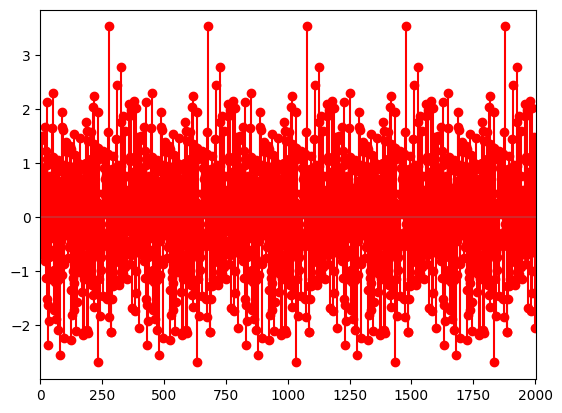

In [60]:
SIGNALplot(y, ny, \
           xlim=[ 0, 5*P ])

Pronto! Agora estamos preparados para analisar sinais no ***domínio da frequência!***